## Bagging vs Random Forest

Both `Bagging` and `Random Forest` are ensemble learning techniques designed
to reduce overfitting by lowering model variance.  
However, Random Forest introduces an additional source of randomness that makes it
more powerful and robust in practice.

---

### Core Idea

- **Bagging** reduces variance by training multiple models on different
  **bootstrap samples** of the data.
- **Random Forest** extends bagging by also using **random feature selection**
  at each split in decision trees.

---

### Key Difference in Randomness

#### Bagging
- Randomness comes only from **bootstrap sampling**
- All features are considered at every split

#### Random Forest
- Randomness comes from:
  - Bootstrap sampling
  - Random subset of features at each split

This extra randomness reduces correlation between trees.

---

### Model Structure

| Aspect | Bagging | Random Forest |
|------|--------|---------------|
| Base estimator | Any model | Decision trees |
| Bootstrap sampling | Yes | Yes |
| Feature randomness | No | Yes |
| Tree correlation | Higher | Lower |

---

### Prediction Mechanism

For classification:
- Both use **majority voting**

For regression:
- Both use **averaging**

---

### Bias–Variance Tradeoff

| Property | Bagging | Random Forest |
|--------|--------|---------------|
| Bias | Similar | Similar |
| Variance | Reduced | Strongly reduced |
| Overfitting control | Good | Better |

Random Forest generally achieves **lower variance** than bagging.

---

### Performance Comparison

- Bagging improves stability compared to a single model
- Random Forest usually achieves higher accuracy
- Random Forest is more robust to noisy and high-dimensional data

---

### Interpretability

| Aspect | Bagging | Random Forest |
|------|--------|---------------|
| Model complexity | Lower | Higher |
| Interpretability | Medium | Lower |
| Feature importance | Limited | Built-in |

---

### When to Use Bagging

Use Bagging when:
- You want a simple variance reduction technique  
- Base model already performs reasonably well  
- Feature randomness is not necessary  

---

### When to Use Random Forest

Use Random Forest when:
- Dataset has many features  
- Features are correlated  
- Strong baseline performance is required  
- Feature importance is useful  

---

### Computational Cost

| Aspect | Bagging | Random Forest |
|------|--------|---------------|
| Training time | Lower | Higher |
| Memory usage | Lower | Higher |

---

### Summary Table

| Criterion | Bagging | Random Forest |
|--------|--------|---------------|
| Variance reduction | Good | Excellent |
| Feature randomness | No | Yes |
| Default choice | No | Yes |

---

### Key Takeaways

- Both methods reduce variance and overfitting  
- Random Forest is an enhanced version of Bagging  
- Extra feature randomness makes Random Forest more powerful  
- Random Forest is generally preferred in real-world applications  

Bagging is conceptually simpler, but Random Forest is usually the better choice
for most practical machine learning problems.


In [1]:
%%capture
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree

In [4]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()
     

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.489544,-3.235214,-0.072710,3.426069,-1.633662,0
1,-1.030310,0.446724,0.087012,0.456276,1.549392,0
2,-1.881018,-0.453834,-1.341170,-0.461625,-0.252719,1
3,1.850618,0.375282,-2.086891,-0.097268,-0.464795,0
4,-1.530031,-0.298800,-1.649522,-0.664577,-0.425194,1


### Bagging

In [6]:
bag = BaggingClassifier(max_features=2)

In [7]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


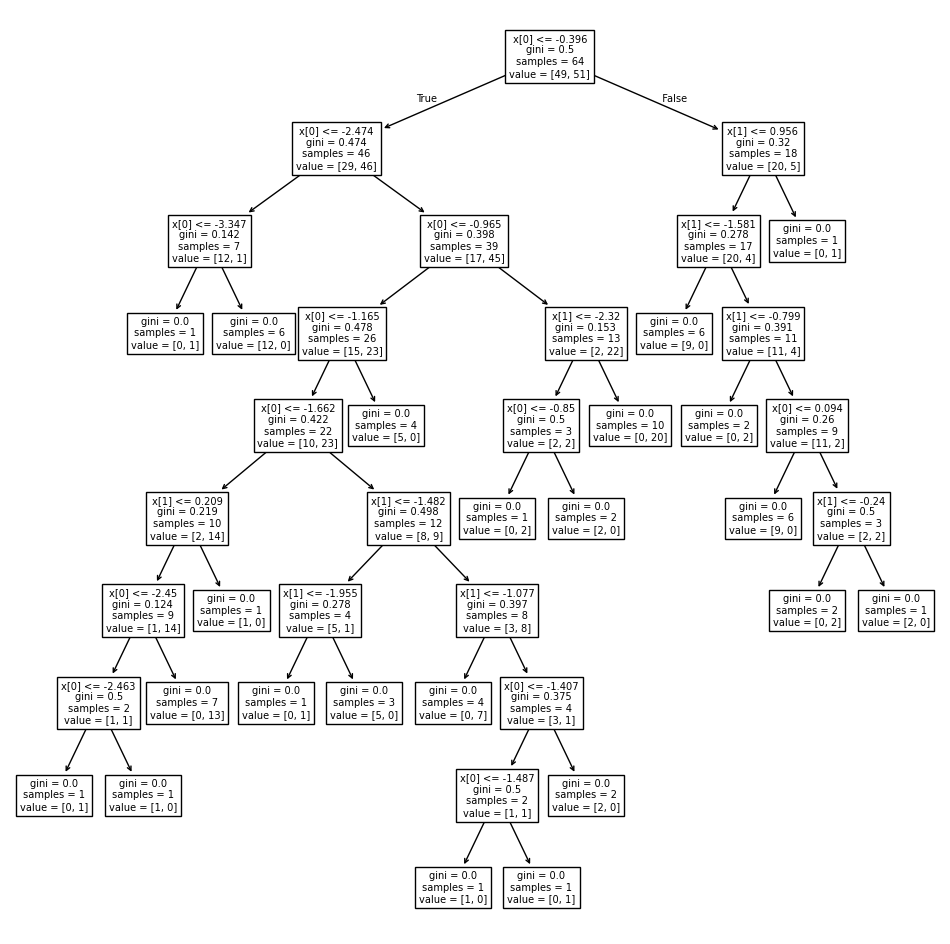

In [8]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

### Random Forest

In [9]:
rf = RandomForestClassifier(max_features=2)

In [10]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


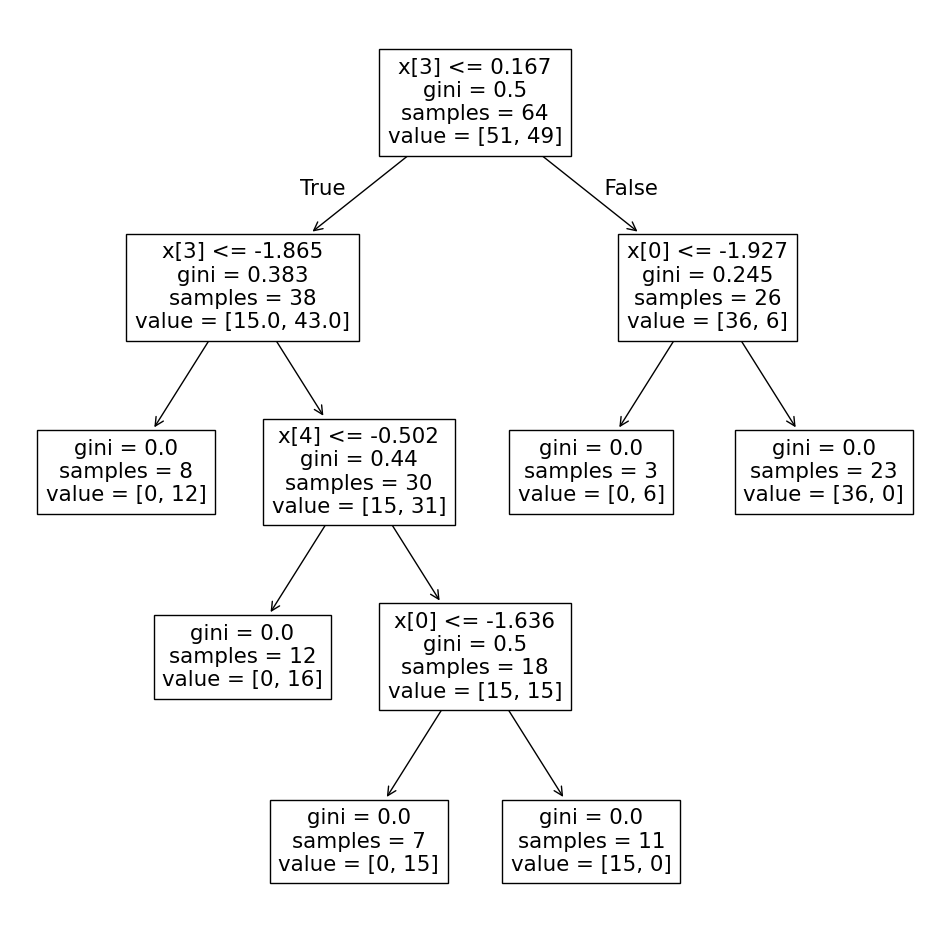

In [11]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()